# Softmax Regression Implementation from Scratch

### 1. Overview
In this script, we will implement **Softmax Regression**, a fundamental algorithm used for multi-class classification problems. Unlike binary classification (which distinguishes between two classes), Softmax Regression allows us to classify inputs into one of $N$ discrete categories.

We will build this model **from scratch** using standard PyTorch tensors and operations, without relying on high-level APIs like `torch.nn.Linear` or `torch.nn.CrossEntropyLoss`. This "bare-metal" approach is essential for understanding the mathematical mechanics underlying modern deep learning frameworks.

### 2. The Task
We will build a model to classify images from the **Fashion-MNIST dataset**.
* **Input:** $28 \times 28$ pixel grayscale images of clothing items.
* **Output:** A probability distribution over 10 classes (e.g., T-shirt, Trouser, Pullover, Dress, Coat, etc.).

### 3. Key Components Implemented
We will manually implement every stage of the learning pipeline:

1.  **Data Pipeline:** Loading and batching data using `torchvision` and `DataLoader`.
2.  **The Model:** A single-layer neural network. We will manually initialize weights ($W$) and biases ($b$) and implement the matrix multiplication operations.
3.  **The Softmax Function:** The mathematical activation function that converts raw model outputs (logits) into valid probabilities that sum to 1.
    $$\text{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}$$
4.  **Cross-Entropy Loss:** The loss function that measures the distance between the predicted probability distribution and the actual truth labels.
5.  **Stochastic Gradient Descent (SGD):** The optimization algorithm that updates the model's weights based on the gradients computed during backpropagation.

### 4. Libraries Used
To ensure this script is portable and standard, we replace all custom wrappers (like `d2l`) with standard libraries:
* **`torch`**: For tensor operations and automatic differentiation (`autograd`).
* **`torchvision`**: For downloading and transforming the dataset.
* **`matplotlib`**: For visualizing the predictions.

### 1. Imports and Data Preparation

We begin by importing the standard PyTorch libraries (`torch`, `torchvision`) and `matplotlib` for visualization. 

Instead of using the wrapper functions from `d2l`, we use `torchvision.datasets.FashionMNIST` to download the dataset. We use `transforms.ToTensor()` to convert the raw image data (PIL images) into floating-point tensors. Finally, we wrap the dataset in `DataLoader` iterators to handle batching and shuffling (for the training set) automatically.

In [5]:
import torch
import torchvision
from torch.utils import data
from torchvision import transforms
import matplotlib.pyplot as plt
# Define the transformation to convert images to PyTorch tensors
trans = transforms.ToTensor()

# Download and load the training data
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True
)

# Download and load the test (validation) data
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True
)

# Create data loaders to read the data in batches
batch_size = 256
train_iter = data.DataLoader(mnist_train, batch_size, shuffle=True)
test_iter = data.DataLoader(mnist_test, batch_size, shuffle=False)

### 2. Initializing Model Parameters

The Fashion-MNIST images are 28x28 pixels. To perform softmax regression, we treat each image as a flat vector of length 784 ($28 \times 28$). 

Since we have 10 distinct classes (t-shirt, dress, etc.), our network needs 10 outputs. We represent our model weights $W$ as a $784 \times 10$ matrix and our biases $b$ as a vector of size 10.

We initialize $W$ with Gaussian random noise (mean 0, standard deviation 0.01) and $b$ with zeros. Crucially, we set `requires_grad=True` so PyTorch can track operations on these tensors to calculate gradients later.

In [6]:
num_inputs=784
num_outputs=10

#initialize the weights and biases of the model
W=torch.normal(0,0.01,size=(num_inputs,num_outputs),requires_grad=True)
b=torch.zeros(num_outputs,requires_grad=True)

### 3. The Softmax Function

Softmax regression transforms the model's outputs (logits) into probabilities. 
The softmax function ensures that:
1. All outputs are non-negative.
2. All outputs sum to 1.

Mathematically, for a given row (sample), we compute:
$$\mathrm{softmax}(\mathbf{X})_{ij} = \frac{\exp(\mathbf{X}_{ij})}{\sum_k \exp(\mathbf{X}_{ik})}$$

The implementation below handles this in three steps:
1. Exponentiate every term.
2. Sum across the rows (dimension 1) to get the normalization constant (partition function).
3. Divide each row by its normalization constant using broadcasting.

In [7]:
def softmax(X):
    """
    Compute the softmax of vector X.
    Args:
        X (tensor): The input tensor of shape (batch_size, num_outputs)
        
    Returns:
        tensor: The probability distribution where rows sum to 1.
    """
    X_exp=torch.exp(X) #size (batch_size, num_outputs)
    partition=X_exp.sum(dim=1,keepdim=True) #size (batch_size, 1)
    return X_exp/partition

def net(X):
    #flatten the image tensor into a matrix of shape (batch_size, 784)
    X_flattened=X.reshape((-1,W.shape[0]))
    return softmax(torch.matmul(X_flattened,W)+b)

### 4. The Cross-Entropy Loss

Cross-entropy takes the negative log-likelihood of the predicted probability assigned to the true label. Mathematically, for a single example where $\mathbf{y}$ is a one-hot vector (with a 1 at the true class index and 0s elsewhere) and $\hat{\mathbf{y}}$ is the predicted probability distribution, the cross-entropy loss is:

$$l(\mathbf{y}, \hat{\mathbf{y}}) = - \sum_{j=1}^q y_j \log \hat{y}_j$$

Because the true label $\mathbf{y}$ only has a value of 1 for the correct class and 0 for all others, the sum disappears. The equation simplifies to just the negative log of the predicted probability for the *true* class. 

For a mini-batch of $n$ examples, we calculate the mean loss across the entire batch:

$$L = - \frac{1}{n} \sum_{i=1}^n \log \hat{y}_{i, y_i}$$

To implement this efficiently without Python `for` loops, we use advanced indexing in PyTorch. The one-hot encoding allows us to pick out the probability of the correct class ($y_i$) for each example in the batch, and then we calculate the `.mean()` across the batch.

In [8]:
def cross_entropy(y_hat,y):
    #y_hat is the predicted probability distribution (output of the softmax function)
    #y is the true label (integer class index)
    #range(len(y_hat)) creates a tensor of indices from 0 to batch_size-1
    #y_hat[[row0, row1, ...], [col0, col1, ...]] selects the predicted probabilities corresponding to the true labels
    #for the first image it looks at y_hat[0, y[0]], for the second image it looks at y_hat[1, y[1]], and so on
    return -torch.log(y_hat[range(len(y_hat)),y]).mean()

### 5. Evaluation Metrics and Optimization Algorithm

Before training, we need a way to track our model's accuracy. We define an `accuracy` function that compares the index of the highest predicted probability against the true label. We also define a helper function to evaluate the accuracy across an entire data loader.

For optimization, we implement Minibatch Stochastic Gradient Descent (SGD). Since our loss function already calculates the mean loss over the batch, we simply multiply the gradients by the learning rate.

In [9]:
def accuracy(y_hat,y):
    #compute the number of correct predictions
    if len(y_hat.shape)>1 and y_hat.shape[1]>1:
        y_hat=y_hat.argmax(axis=1) #get the predicted class index
    #y_hat=[1,2,3], y=[1,2,0] -> cmp=[True, True, False]
    cmp=y_hat.type(y.dtype)==y #compare predicted labels with true labels
    return float(cmp.type(y.dtype).sum()) #sum the number of correct predictions

def evaluate_accuracy(net,data_iter):
    #compute the accuracy of a model on a given dataset
    metric_correct,metric_total=0.0,0.0
    with torch.no_grad(): #disable gradient computation for evaluation
        for X,y in data_iter:
            metric_correct+=accuracy(net(X),y) #accumulate the number of correct predictions
            metric_total+=y.numel() #accumulate the total number of samples
        return metric_correct/metric_total #return the overall accuracy

def sgd(params,lr):
    #minibatch stochastic gradient descent
    with torch.no_grad(): #disable gradient computation for parameter updates
        for param in params:
            param-=lr*param.grad #update the parameter by moving in the direction of the negative gradient
            param.grad.zero_() #reset the gradient to zero after updating

### 6. The Training Loop

Since we aren't using the `d2l.Trainer` class, we write a standard PyTorch training loop from scratch. For a set number of epochs, we iterate over the training batches, compute the forward pass, calculate the loss, run backpropagation to get the gradients, and update the parameters using our SGD function. We print the metrics at the end of each epoch.

In [10]:
lr=0.1
num_epochs=5

for epoch in range(num_epochs):
    #initialize the sums for loss and accuracy, and the total number of samples
    train_loss_sum=0.0
    train_acc_sum=0.0
    total_samples=0.0

    #training phase
    for X,y in train_iter:
        #forward pass: compute the predicted probabilities and the loss
        y_hat=net(X)
        loss=cross_entropy(y_hat,y)

        #backward pass
        #stores the gradients of the loss with respect to W and b in W.grad and b.grad
        loss.backward()
         #update the parameters:
        sgd([W,b],lr)
        
        #track metrics
        #loss.item() gives the value of each batch's loss as a scalar,use y.numel to un-average the loss (loss per sample * number of samples in the batch)
        train_loss_sum+=loss.item()*y.numel() #accumulate the total loss (loss per sample * number of samples in the batch)
        train_acc_sum+=accuracy(y_hat,y)
        total_samples+=y.numel() #accumulate the total number of samples

    #validation phase
    val_acc=evaluate_accuracy(net,test_iter)

    #calculate average loss and accuracy for the epoch
    avg_train_loss=train_loss_sum/total_samples
    avg_train_acc=train_acc_sum/total_samples
    print(f"Epoch {epoch+1}: Loss={avg_train_loss:.4f}, Train Acc={avg_train_acc:.4f}, Val Acc={val_acc:.4f}")


Epoch 1: Loss=0.7844, Train Acc=0.7521, Val Acc=0.7773
Epoch 2: Loss=0.5701, Train Acc=0.8135, Val Acc=0.8109
Epoch 3: Loss=0.5249, Train Acc=0.8248, Val Acc=0.8168
Epoch 4: Loss=0.5004, Train Acc=0.8319, Val Acc=0.8194
Epoch 5: Loss=0.4845, Train Acc=0.8364, Val Acc=0.8257


### 7. Prediction

Now that training is complete, our model is ready to classify some images. We grab a batch of data from the test iterator, run it through the model, and plot the images alongside their true and predicted labels.

Predicted labels: tensor([9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 5, 3, 4, 1, 2, 6, 8, 0, 0, 7, 7, 5,
        1, 2, 6, 3, 9, 3, 8, 8, 3, 3, 8, 0, 7, 5, 7, 9, 0, 1, 3, 9, 6, 7, 2, 1,
        4, 6, 6, 2, 5, 6, 2, 2, 8, 4, 8, 0, 7, 7, 8, 5, 1, 1, 3, 4, 7, 8, 7, 0,
        6, 6, 2, 3, 1, 2, 8, 4, 1, 8, 5, 9, 5, 0, 3, 2, 0, 6, 5, 3, 6, 7, 1, 8,
        0, 1, 6, 2, 3, 6, 7, 2, 7, 8, 5, 9, 9, 4, 2, 5, 7, 0, 5, 2, 8, 4, 7, 8,
        0, 0, 9, 9, 3, 0, 8, 4, 1, 5, 4, 1, 9, 1, 8, 4, 6, 1, 2, 5, 1, 0, 0, 0,
        1, 6, 1, 3, 2, 2, 6, 2, 1, 3, 5, 0, 4, 7, 9, 3, 7, 2, 3, 9, 0, 9, 4, 7,
        4, 2, 6, 5, 2, 1, 2, 1, 3, 0, 9, 1, 0, 9, 3, 8, 7, 9, 9, 4, 4, 7, 1, 2,
        1, 6, 3, 2, 8, 3, 6, 1, 1, 0, 2, 9, 2, 4, 0, 7, 9, 8, 4, 1, 8, 4, 1, 3,
        1, 2, 7, 4, 8, 5, 3, 0, 7, 7, 6, 6, 7, 0, 7, 8, 9, 2, 9, 0, 5, 1, 4, 2,
        5, 4, 9, 6, 2, 8, 6, 4, 6, 4, 9, 7, 4, 5, 5, 4])


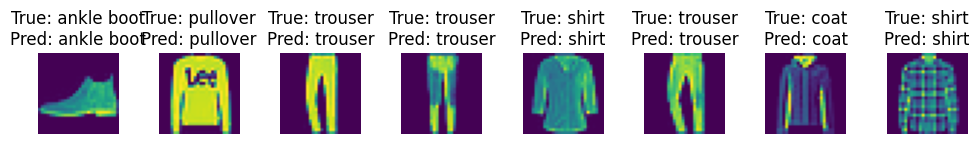

In [11]:
# Grab a single batch from the test set
X_batch, y_batch = next(iter(test_iter))

#make predictions on the batch
preds=net(X_batch).argmax(axis=1)
print("Predicted labels:", preds)

#map numeric labels to class names
def get_fashion_mnist_labels(labels):
    text_labels=["t-shirt","trouser","pullover","dress","coat","sandal","shirt","sneaker","bag","ankle boot"]
    return [text_labels[int(i)] for i in labels]

#select the first 8 images to display
n=8
X_show=X_batch[:n]
y_true=get_fashion_mnist_labels(y_batch[:n])
y_pred=get_fashion_mnist_labels(preds[:n])

#plotting
fig,axes=plt.subplots(1,n,figsize=(12,1.5))
for i, ax in enumerate(axes):
    #reshape the tensor to 28x28 and convert to numpy array for plotting
    ax.imshow(X_show[i].squeeze().numpy(), cmap="viridis")
    ax.set_title(f"True: {y_true[i]}\nPred: {y_pred[i]}")
    ax.axis("off")
plt.subplots_adjust(wspace=0.5)
plt.show()
